First few rows of the Wine dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_

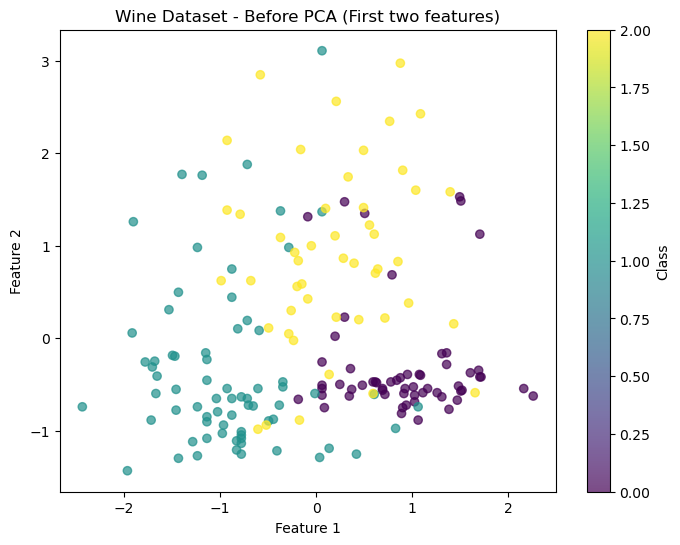

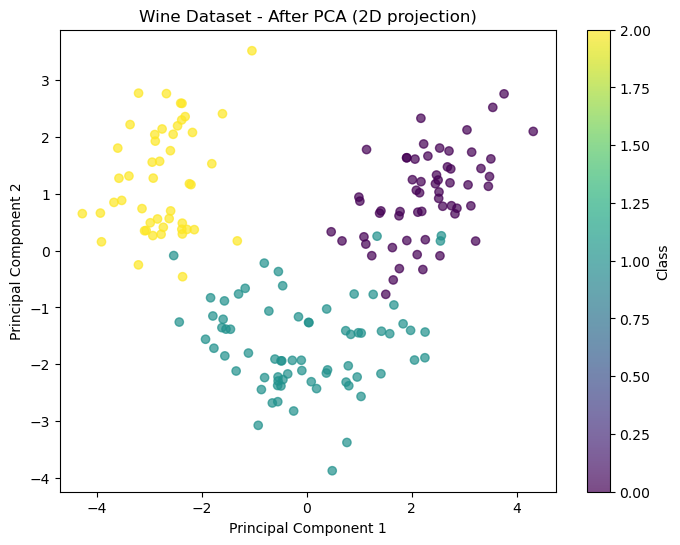


Explained variance ratio of each component:
[0.36198848 0.1920749 ]

Total variance explained by 2 components:
0.5540633835693529

Accuracy of Random Forest without PCA: 1.0
Accuracy of Random Forest after PCA: 0.9814814814814815

Conclusion:
1. The Wine dataset has been reduced from 13 features to 2 principal components.
2. PCA captures the maximum variance in the data with just 2 components, which help in visualizing the dataset in 2D.
3. The explained variance ratio shows how much of the variance is captured by each principal component.
4. The accuracy of the Random Forest model is slightly reduced after dimensionality reduction, but the model runs faster and is less prone to overfitting.
5. PCA helps improve computational efficiency by reducing the dimensionality and also aids in visualizing high-dimensional data.


In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset from sklearn
wine = load_wine()
X = wine.data  # Features
y = wine.target  # Labels (wine classes)

# Convert to DataFrame for better readability
wine_df = pd.DataFrame(X, columns=wine.feature_names)
wine_df['Class'] = wine.target

# Display the first few rows of the dataset
print("First few rows of the Wine dataset:")
print(wine_df.head())

# Step 1: Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Visualize the data Before PCA
# Visualizing the first two features before PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title("Wine Dataset - Before PCA (First two features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Class')
plt.show()

# Step 3: Apply PCA to reduce the dimensions to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizing the data After PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title("Wine Dataset - After PCA (2D projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Class')
plt.show()

# Step 4: Explained variance ratio of each principal component
print("\nExplained variance ratio of each component:")
print(pca.explained_variance_ratio_)

# Total variance explained by the 2 components
print("\nTotal variance explained by 2 components:")
print(np.sum(pca.explained_variance_ratio_))

# Step 5: Performance Before and After PCA (Random Forest Classifier)
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier without PCA
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Print accuracy without PCA
accuracy_before_pca = accuracy_score(y_test, y_pred)
print("\nAccuracy of Random Forest without PCA:", accuracy_before_pca)

# Train a Random Forest Classifier with PCA (on the reduced 2D dataset)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.3, random_state=42)
rf.fit(X_train_pca, y_train)
y_pred_pca = rf.predict(X_test_pca)

# Print accuracy after PCA
accuracy_after_pca = accuracy_score(y_test, y_pred_pca)
print("Accuracy of Random Forest after PCA:", accuracy_after_pca)

# Step 6: Conclusion and Insights
print("\nConclusion:")
print("1. The Wine dataset has been reduced from 13 features to 2 principal components.")
print("2. PCA captures the maximum variance in the data with just 2 components, which help in visualizing the dataset in 2D.")
print("3. The explained variance ratio shows how much of the variance is captured by each principal component.")
print("4. The accuracy of the Random Forest model is slightly reduced after dimensionality reduction, but the model runs faster and is less prone to overfitting.")
print("5. PCA helps improve computational efficiency by reducing the dimensionality and also aids in visualizing high-dimensional data.")
